In [2]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(context="notebook",style="whitegrid",palette="dark")
import numpy as np

In [4]:
data=pd.read_csv("ex1data2.txt",names=["square","bedrooms","price"])
data.head()

,square,bedrooms,price
0,2104,3,399900
1,1600,3,329900
2,2400,3,369000
3,1416,2,232000
4,3000,4,539900


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   square    47 non-null     int64
 1   bedrooms  47 non-null     int64
 2   price     47 non-null     int64
dtypes: int64(3)
memory usage: 1.2 KB


In [6]:
# 标准化数据
def normalize_feature(data):
    return data.apply(lambda column: (column - column.mean()) / column.std())
data=normalize_feature(data)
data.head()

,square,bedrooms,price
0,0.130010,-0.223675,0.475747
1,-0.504190,-0.223675,-0.084074
2,0.502476,-0.223675,0.228626
3,-0.735723,-1.537767,-0.867025
4,1.257476,1.090417,1.595389


In [8]:
def get_x(data):
    data.insert(0,"ones",1)
    return data.iloc[:,:-1].values

def get_y(data):
    return data.iloc[:,-1:].values

X=get_x(data)
Y=get_y(data)
print(X)
print(Y)

[[ 1.00000000e+00  1.30009869e-01 -2.23675187e-01]
 [ 1.00000000e+00 -5.04189838e-01 -2.23675187e-01]
 [ 1.00000000e+00  5.02476364e-01 -2.23675187e-01]
 [ 1.00000000e+00 -7.35723065e-01 -1.53776691e+00]
 [ 1.00000000e+00  1.25747602e+00  1.09041654e+00]
 [ 1.00000000e+00 -1.97317285e-02  1.09041654e+00]
 [ 1.00000000e+00 -5.87239800e-01 -2.23675187e-01]
 [ 1.00000000e+00 -7.21881404e-01 -2.23675187e-01]
 [ 1.00000000e+00 -7.81023044e-01 -2.23675187e-01]
 [ 1.00000000e+00 -6.37573110e-01 -2.23675187e-01]
 [ 1.00000000e+00 -7.63567023e-02  1.09041654e+00]
 [ 1.00000000e+00 -8.56737193e-04 -2.23675187e-01]
 [ 1.00000000e+00 -1.39273340e-01 -2.23675187e-01]
 [ 1.00000000e+00  3.11729182e+00  2.40450826e+00]
 [ 1.00000000e+00 -9.21956312e-01 -2.23675187e-01]
 [ 1.00000000e+00  3.76643089e-01  1.09041654e+00]
 [ 1.00000000e+00 -8.56523009e-01 -1.53776691e+00]
 [ 1.00000000e+00 -9.62222960e-01 -2.23675187e-01]
 [ 1.00000000e+00  7.65467909e-01  1.09041654e+00]
 [ 1.00000000e+00  1.29648433e+

In [9]:
X_tensor=torch.from_numpy(X).float()
Y_tensor=torch.from_numpy(Y).float()

In [11]:
theta=torch.zeros((X.shape[1],1),requires_grad=True)

print("初始参数 theta:")
print(theta)

初始参数 theta:
tensor([[0.],
        [0.],
        [0.]], requires_grad=True)


In [13]:
alpha =0.01
epochs=1200
m=X.shape[0]

In [1]:
costs=[]
for i in range(epochs):
    y_hat=X_tensor@theta
    loss=torch.sum((y_hat-Y_tensor)**2)/(2*m)
    costs.append(loss.item())
    loss.backward()

    with torch.no_grad():
        theta-=theta.grad*alpha
        theta.grad.zero_()
        
    if i % 100 == 0:
        print(f"Epoch {i}: Cost = {loss.item():.4f}")

print("\n训练完成！")
print(f"最终的 theta 为:\n{theta.detach().numpy()}")

NameError: name 'epochs' is not defined

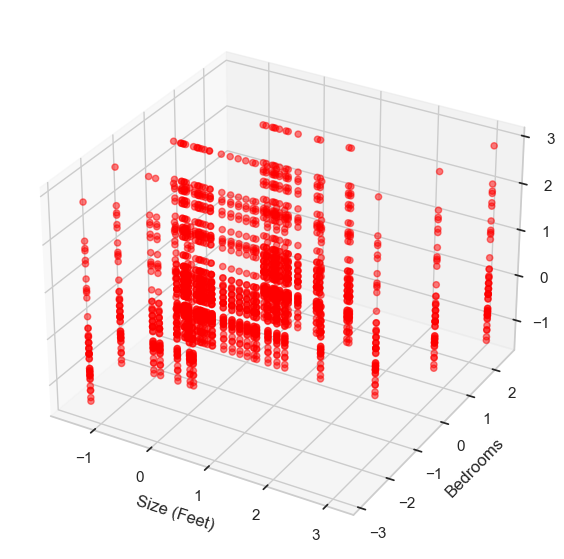

In [17]:
from mpl_toolkits.mplot3d import Axes3D # 必须导入这个来启用 3D 模式

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d') # 创建 3D 坐标系

# 假设 X_tensor 的第 1 列是面积，第 2 列是卧室数
x1 = X_tensor[:, 1].numpy()
x2 = X_tensor[:, 2].numpy()
y_true = Y_tensor.numpy()

ax.scatter(x1, x2, y_true, c='red', marker='o', alpha=0.5)

ax.set_xlabel('Size (Feet)')
ax.set_ylabel('Bedrooms')
ax.set_zlabel('Price')
plt.show()

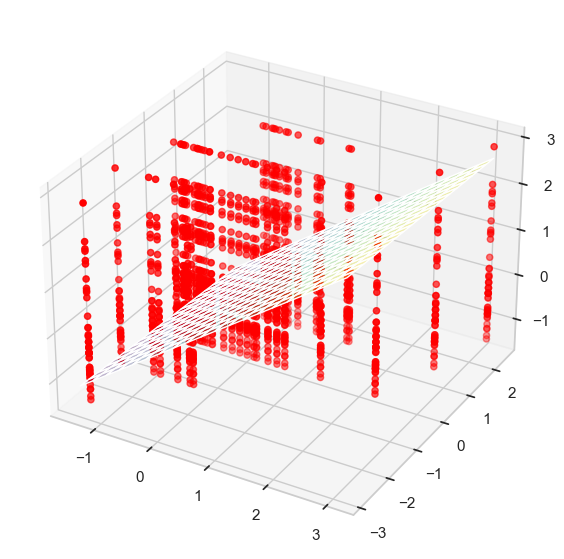

In [18]:
# 1. 创建网格数据 (涵盖特征 1 和 特征 2 的范围)
x1_range = np.linspace(x1.min(), x1.max(), 20)
x2_range = np.linspace(x2.min(), x2.max(), 20)
x1_mesh, x2_mesh = np.meshgrid(x1_range, x2_range)

# 2. 用训练好的 theta 计算预测高度 (Z轴)
# 这里的公式依然是: y = theta[0] + theta[1]*x1 + theta[2]*x2
# 注意：你的 theta 现在是一个 (3, 1) 的向量
t = theta.detach().numpy()
z_mesh = t[0] + t[1] * x1_mesh + t[2] * x2_mesh

# 3. 绘图
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 画平面 (alpha=0.3 让它半透明，能看到底下的点)
ax.plot_surface(x1_mesh, x2_mesh, z_mesh, cmap='viridis', alpha=0.3)

# 同时画上原始散点
ax.scatter(x1, x2, y_true, c='red', marker='o')

plt.show()

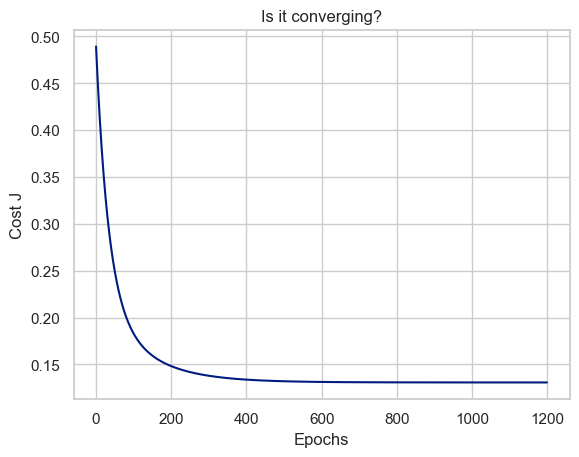

In [21]:
plt.plot(costs)
plt.title("Is it converging?")
plt.xlabel("Epochs")
plt.ylabel("Cost J")
plt.show()

In [23]:
theta_np=theta.detach().numpy()
print(theta_np)

[[ 1.1548402e-09]
 [ 8.8212460e-01]
 [-5.0537344e-02]]


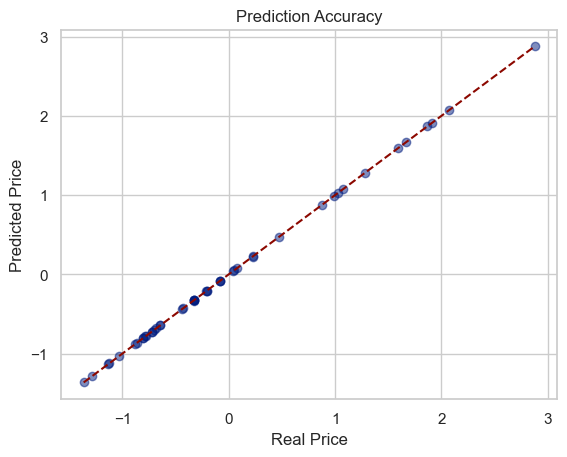

In [24]:
plt.scatter(Y_tensor.numpy(), Y, alpha=0.5)
plt.plot([Y_tensor.min(), Y_tensor.max()], [Y_tensor.min(), Y_tensor.max()], 'r--') # 画一条 45 度的参考线
plt.xlabel('Real Price')
plt.ylabel('Predicted Price')
plt.title('Prediction Accuracy')
plt.show()